<div style="display:flex; justify-content:space-between; align-items:flex-start;">
    <img src="./logo_UNSAM.jpg" width="130">
</div>

<div style="text-align:center; margin-top:80px;">

<h1 style="margin-bottom:10px;">Análisis y Procesamiento de Señales</h1>
    
<h2 style="margin-top:0; font-weight:normal;">
        Trabajo Semanal Nº 7
</h2>

<br><br>

<p style="font-size:18px;">
        Mora De La Corte
</p>

<p style="font-size:16px;">
       1º Cuatrimestre 2026
</p>

</div>

# Consigna

Usando el archivo ecg.mat que contiene un registro electrocardiográfico (ECG) registrado durante una prueba de esfuerzo, junto con una serie de variables descriptadas a continuación. Diseñe y aplique los filtros digitales necesarios para mitigar las siguientes fuentes de contaminación:

- Ruido causado por el movimiento de los electrodos (Alta frecuencia).
- Ruido muscular (Alta frecuencia).
- Movimiento de la línea de base del ECG, inducido en parte por la respiración (Baja frecuencia).

**Ayuda:** Los detalles de cómo acceder a ecg.mat los pueden encontrar en lectura_sigs.py

## *Archivo ECG.mat*

*(variables)*

- ***ecg_lead***: Registro de ECG muestreado a *fs* = 1 kHz durante una prueba de esfuerzo
- ***qrs_pattern1***: Complejo de ondas QRS normal
- ***heartbeat_pattern1***: Latido normal
- ***heartbeat_pattern2***: Latido de origen ventricular
- ***qrs_detections***: vector con las localizaciones (en # de muestras) donde ocurren los latidos


**Se pide:**

**a)** Establezca una plantilla de diseño para los filtros digitales que necesitará para que la señal de ECG se asemeje a los latidos promedio en cuanto a suavidad de los trazos y nivel isoeléctrico nulo.

**Ayuda:** Utilice los resultados del ancho de banda estimado del ECG **en la Tarea Semanal 5**. Tome como referencia las siguientes morfologías promedio para evaluar cualitativamente la efectividad de los filtros diseñados.

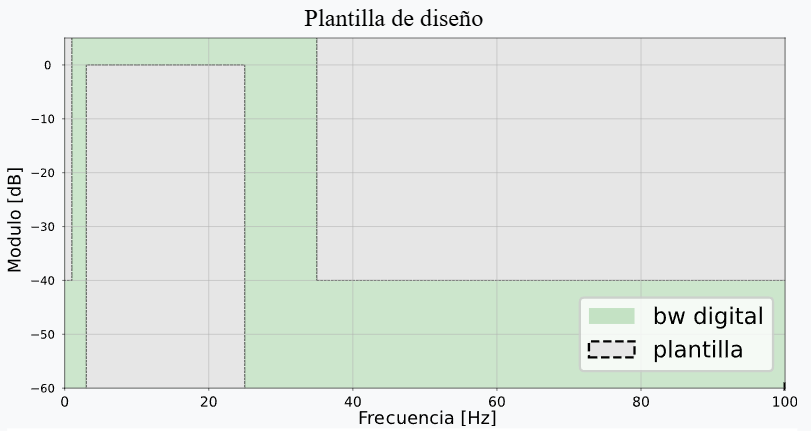
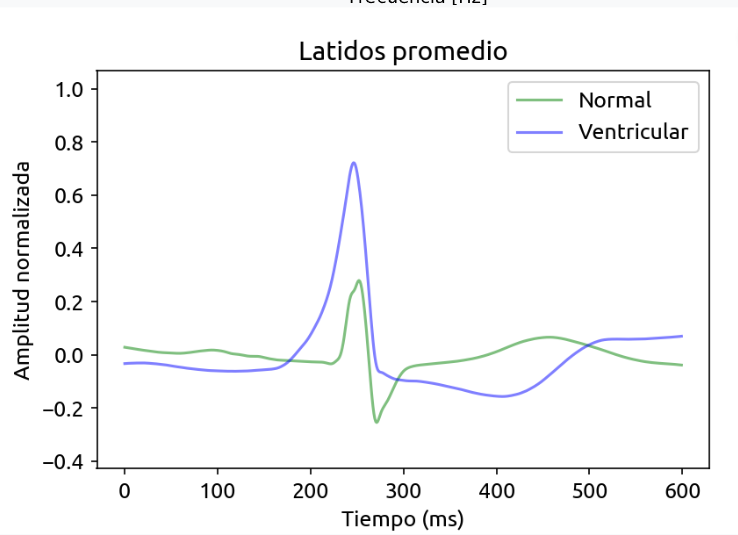
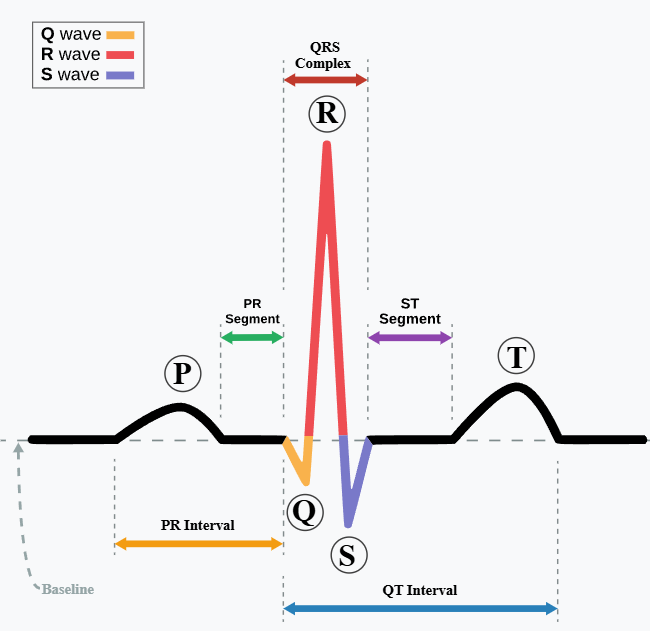


In [ ]:
#############
# Plantilla #
#############
 
nyq_frec = fs/2
ripple = 1 # dB
atenuacion = 40 # dB
 
ws1 = ?? # Hz
wp1 = ?? # Hz
wp2 = ?? # Hz
ws2 = ?? # Hz
 
# plantilla normalizada a Nyquist en dB
frecs = np.array([0.0,         ws1,         wp1,     wp2,     ws2,         nyq_frec   ]) / nyq_frec
gains = np.array([-atenuacion, -atenuacion, -ripple, -ripple, -atenuacion, -atenuacion])
 
# convertimos a veces para las funciones de diseño
gains = 10**(gains/20)

**b)** ¿Cómo obtuvo dichos valores? Describa el procedimiento para establecer los valores de la plantilla.

**c)** Diseñe **al menos** dos filtros FIR y dos IIR para su comparación. Verifique que la respuesta en frecuencia responda a la plantilla de diseño.

**Ayuda:** Para los filtros IIR adopte las aproximaciones de módulo de [máxima planicidad, Chebyshev y Cauer](). Para los FIR, utilice las metodologías de [ventanas, cuadrados mínimos]() y [Parks-Mc Clellan-Remez](). Todos implementados en [SciPy.Signal]()

**d)** Evalúe el rendimiento de los filtros que haya diseñado:

1. Verifique que filtra las señales interferentes.
2. Verifique que es inocuo en las zonas donde no hay interferentes.

**Ayuda:** Utilice el siguiente código como referencia para analizar los puntos 1 y 2). **También puede incluir otras regiones que considere de interés.**

In [ ]:
 
###################################
#%% Regiones de interés con ruido #
###################################
 
regs_interes = (
        [4000, 5500], # muestras
        [10e3, 11e3], # muestras
        )
 
for ii in regs_interes:
   
    # intervalo limitado de 0 a cant_muestras
    zoom_region = np.arange(np.max([0, ii[0]]), np.min([cant_muestras, ii[1]]), dtype='uint')
   
    plt.figure(1)
    plt.plot(zoom_region, ecg_one_lead[zoom_region], label='ECG', linewidth=2)
    #plt.plot(zoom_region, ECG_f_butt[zoom_region], label='Butterworth')
    #plt.plot(zoom_region, ECG_f_win[zoom_region + demora], label='FIR Window')
   
    plt.title('ECG filtering example from ' + str(ii[0]) + ' to ' + str(ii[1]) )
    plt.ylabel('Adimensional')
    plt.xlabel('Muestras (#)')
   
    axes_hdl = plt.gca()
    axes_hdl.legend()
    axes_hdl.set_yticks(())
           
    plt.show()
 
###################################
#%% Regiones de interés sin ruido #
###################################
 
regs_interes = (
        np.array([5, 5.2]) *60*fs, # minutos a muestras
        np.array([12, 12.4]) *60*fs, # minutos a muestras
        np.array([15, 15.2]) *60*fs, # minutos a muestras
        )
 
for ii in regs_interes:
   
    # intervalo limitado de 0 a cant_muestras
    zoom_region = np.arange(np.max([0, ii[0]]), np.min([cant_muestras, ii[1]]), dtype='uint')
   
    plt.figure(2)
    plt.plot(zoom_region, ecg_one_lead[zoom_region], label='ECG', linewidth=2)
    #plt.plot(zoom_region, ECG_f_butt[zoom_region], label='Butterworth')
    plt.plot(zoom_region, ECG_f_win[zoom_region + demora], label='FIR Window')
   
    plt.title('ECG filtering example from ' + str(ii[0]) + ' to ' + str(ii[1]) )
    plt.ylabel('Adimensional')
    plt.xlabel('Muestras (#)')
   
    axes_hdl = plt.gca()
    axes_hdl.legend()
    axes_hdl.set_yticks(())
           
    plt.show()

**Bonus:**

- 💎 Proponga algún tipo de señal, ya sea de la TS anterior u otra que no haya sido analizada y repita el análisis. No olvide explicar su origen y cómo fue digitalizada.

# Plantilla de diseño 


Se comienza por importar las librerías necesarias y cargar el archivo de señal sobre el cual se desarrollará el trabajo.

In [2]:
import numpy as np
from scipy import signal as sig

import matplotlib.pyplot as plt
   
import scipy.io as sio

sio.whosmat('ECG_TP4.mat')
mat_struct = sio.loadmat('ECG_TP4.mat')

ecg_one_lead = mat_struct['ecg_lead']
N = len(ecg_one_lead)

hb_1 = mat_struct['heartbeat_pattern1']
hb_2 = mat_struct['heartbeat_pattern2']

ecg_one_lead = mat_struct['ecg_lead'].flatten()

# Si se desea visualizar los datos ... 

# plt.figure()
# plt.plot(ecg_one_lead[5000:12000]) # Esta limitado porque son demasiados datos
# plt.grid(True, linestyle='--', alpha=0.5)

# plt.figure()
# plt.plot(hb_1)

# plt.figure()
# plt.plot(hb_2)

A continuación se define la plantilla que será utilizada como guía para el diseño de los filtros. El objetivo es mitigar las diversas fuentes de contaminación que afectan la correcta lectura de la señal ECG:

- Ruido de alta frecuencia causado por el movimiento de los electrodos.
- Ruido muscular (alta frecuencia).
- Deriva de la línea de base, inducida principalmente por la respiración (baja frecuencia).

Dado este conjunto de interferencias, se adopta un esquema de filtrado pasabanda, con los siguientes parámetros:

$$ws1 \rightarrow 0.1 Hz$$

$$wp1 \rightarrow 0.5 Hz$$

$$wp2 \rightarrow 35 Hz$$

$$ws2 \rightarrow 45 Hz$$

La elección de estos valores responde a criterios clínicos y de procesamiento de señales propios de registros electrocardiográficos, y se justifica a continuación.

**Límite inferior (ws1 = 0.1 Hz, wp1 = 0.5 Hz):** el movimiento respiratorio del paciente y los cambios de impedancia en la interfaz electrodo-piel introducen una deriva de muy baja frecuencia (típicamente entre 0.05 Hz y 1 Hz). Fijar wp1 = 0.5 Hz con una atenuación mínima de 40 dB en ws1 = 0.1 Hz permite suprimir esta perturbación de forma drástica, logrando un nivel isoeléctrico nulo y estable.


**Límite superior de la banda de paso (wp2 = 35 Hz):** el ancho de banda típico de una señal ECG se encuentra entre 0.05 Hz y 150 Hz, aunque la mayor parte de la energía clínicamente relevante (incluyendo el complejo QRS) se concentra por debajo de los 40 Hz. Fijar wp2 = 35 Hz (Valor parecido al obtenido en la TS5) permite conservar el contenido espectral significativo de la señal, garantizando que los picos de las ondas R no sufran una atenuación excesiva (menor a 3 dB) y preservando tanto la suavidad de los trazos como la amplitud real de los latidos.


**Límite de la banda de rechazo superior (ws2 = 45 Hz):** al iniciar la banda de rechazo en 45 Hz con una atenuación de 40 dB, el filtro atenúa de forma eficaz cualquier acople proveniente de la red eléctrica de 50 Hz, eliminando el zumbido característico sin necesidad de incorporar un filtro notch adicional.


In [3]:
def limites_plantilla():
    ws1 = 0.1
    wp1 = 0.5
    wp2 = 35
    ws2 = 45

    f_min, f_max = 0, 100
    gain_min, gain_max = -60, 5

    # Banda de rechazo inferior (0 a ws1): Prohibido arriba de -40 dB
    plt.fill_between([0, ws1], -40, gain_max, color='red', alpha=0.3, label='Zona Prohibida')

    # Banda de paso (wp1 a wp2): 
    # Prohibido abajo de -3 dB (tolerancia de rizado) y arriba de 0 dB
    plt.fill_between([wp1, wp2], gain_min, -3, color='red', alpha=0.3)
    plt.fill_between([wp1, wp2], 0, gain_max, color='red', alpha=0.3)

    # Banda de rechazo superior (ws2 a 100 Hz): Prohibido arriba de -40 dB
    plt.fill_between([ws2, f_max], -40, gain_max, color='red', alpha=0.3)

    frecuencias = [ws1, wp1, wp2, ws2]
    etiquetas = [f'ws1 = {ws1}', f'wp1 = {wp1}', f'wp2 = {wp2}', f'ws2 = {ws2}']
    colores = ['darkred', 'darkgreen', 'darkgreen', 'darkred']

    plt.axhline(y=-40, color='gray', linestyle='-', alpha=0.5)
    plt.axhline(y=0, color='gray', linestyle='-', alpha=0.5)

    plt.xlim(f_min, f_max)
    plt.ylim(gain_min, gain_max)
    
    return

Podemos visualizar la plantilla con el siguiente bloque de código.

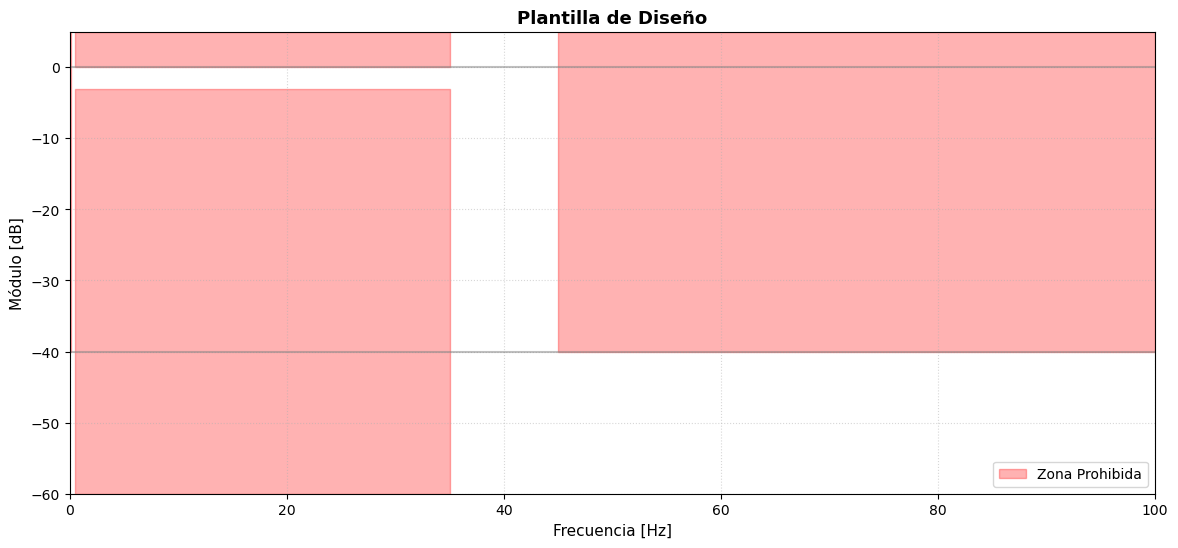

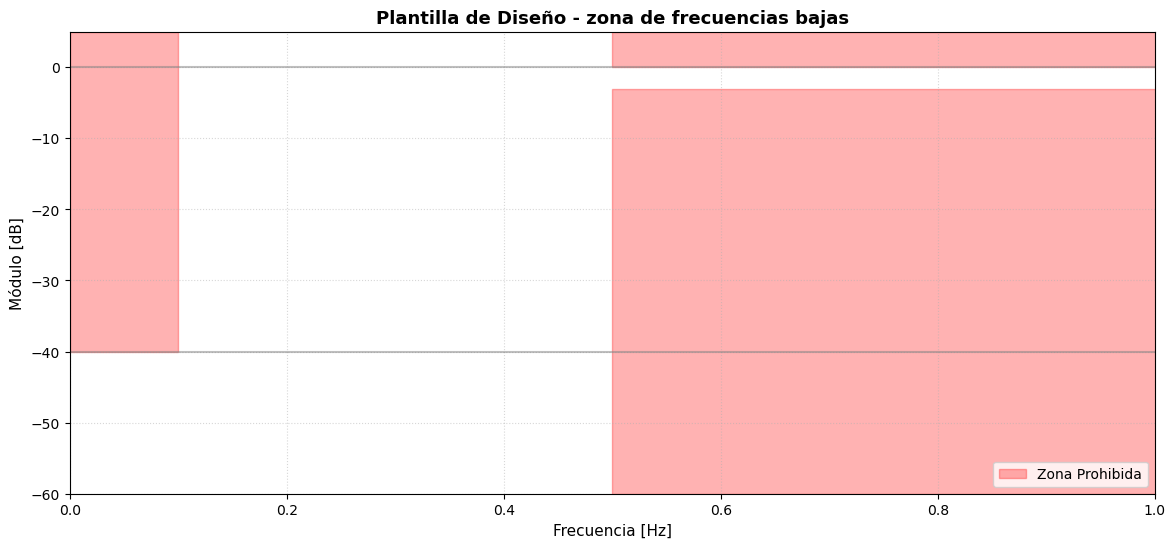

In [4]:
plt.figure(figsize=(14, 6))
limites_plantilla() # Llamo a la funcion para establecer los limites de la plantilla
plt.xlabel('Frecuencia [Hz]', fontsize=11)
plt.ylabel('Módulo [dB]', fontsize=11)
plt.title('Plantilla de Diseño', fontsize=13, fontweight='bold')
plt.grid(True, which='both', linestyle=':', alpha=0.5)
plt.legend(loc='lower right')
plt.show()

# Zoom para visualizar mejor las frecuencias bajas

plt.figure(figsize=(14, 6))
limites_plantilla() # Llamo a la funcion para establecer los limites de la plantilla
plt.xlim(0, 1)
plt.xlabel('Frecuencia [Hz]', fontsize=11)
plt.ylabel('Módulo [dB]', fontsize=11)
plt.title('Plantilla de Diseño - zona de frecuencias bajas', fontsize=13, fontweight='bold')
plt.grid(True, which='both', linestyle=':', alpha=0.5)
plt.legend(loc='lower right')
plt.show()

# Filtros IIR


## Diseño de los filtros IIR

Con la plantilla de diseño establecida, se procede al diseño de filtros del tipo IIR *(Infinite Impulse Response)*. A diferencia de los filtros FIR, los filtros IIR pueden alcanzar los requerimientos de atenuación especificados con un orden significativamente menor, a costa de introducir fase no lineal. 

Para el diseño se utilizó la función iirdesign de scipy.signal, evaluando cuatro aproximaciones clásicas: Butterworth, Chebyshev I, Chebyshev II y Cauer (elíptico).

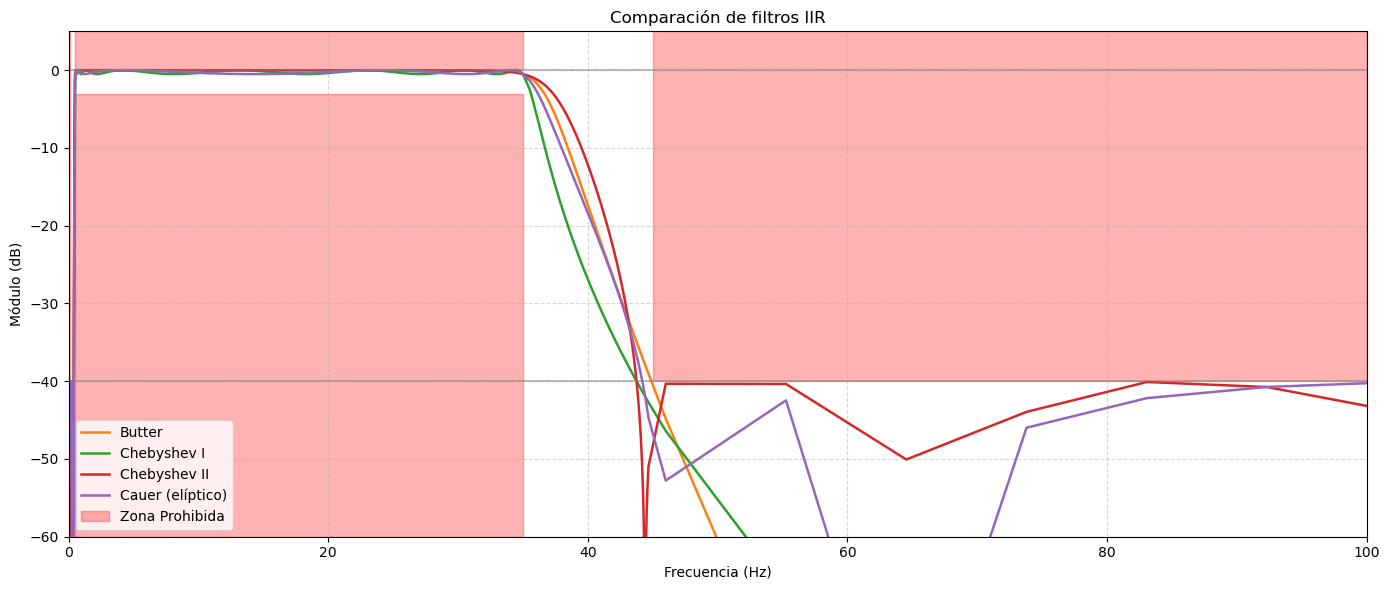

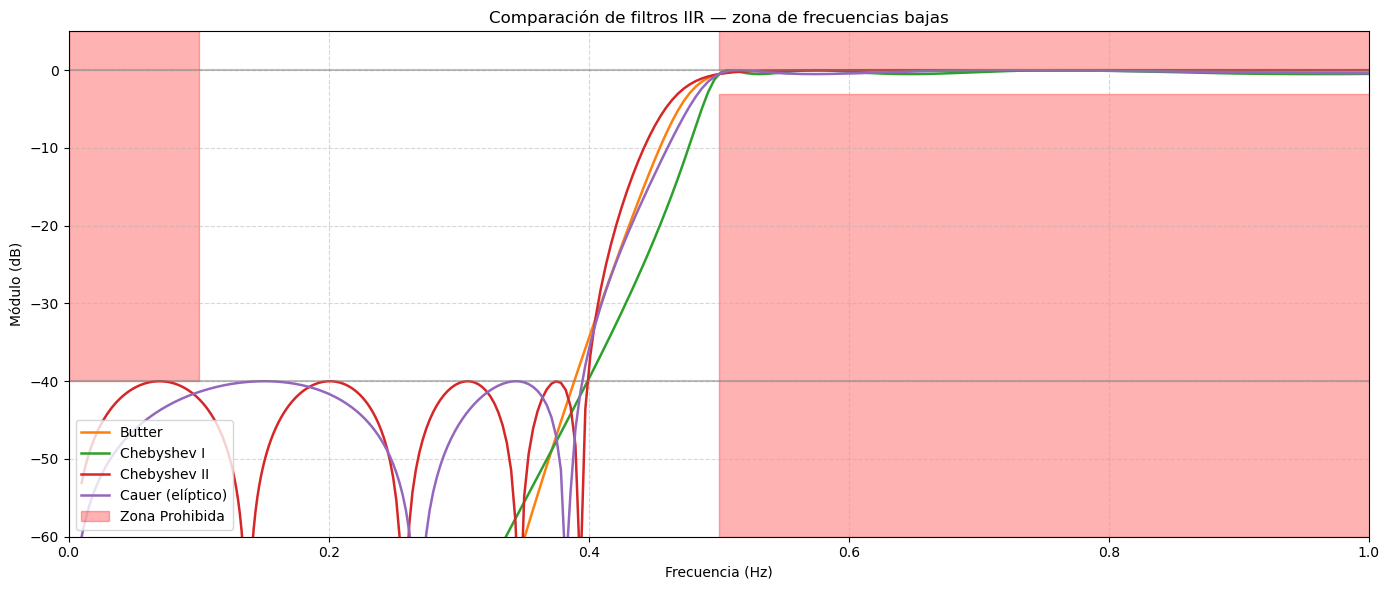

In [5]:
fs = 1000 # fs_ecg 

nyq_frec = fs/2
ripple = 1 # dB
atenuacion = 40 # dB
 
ws1 = 0.1
wp1 = 0.5
wp2 = 35
ws2 = 45

wp_iir = [wp1, wp2]
ws_iir = [ws1, ws2]

sos_but = sig.iirdesign(wp_iir, ws_iir, ripple/2, atenuacion, analog=False, ftype='butter', output='sos', fs=fs)
sos_chb1 = sig.iirdesign(wp_iir, ws_iir, ripple/2, atenuacion, analog=False, ftype='cheby1', output='sos', fs=fs)
sos_chb2 = sig.iirdesign(wp_iir, ws_iir, ripple/2, atenuacion, analog=False, ftype='cheby2', output='sos', fs=fs)
sos_cau = sig.iirdesign(wp_iir, ws_iir, ripple/2, atenuacion, analog=False, ftype='cauer', output='sos', fs=fs)

# Eje de frecuencias personalizado

ww = np.concatenate([np.logspace(start=-2,stop = 0.1, num = 500),
                     np.linspace(start = 1.26,stop = 35, num = 200),
                     np.logspace(start=1.55,stop = 1.65, num = 300),
                     np.linspace(start = 46,stop = fs//2, num = 50)])

filtros = [
    (sos_but,  'Butter',           'C1', '-'),
    (sos_chb1, 'Chebyshev I',      'C2', '-'),
    (sos_chb2, 'Chebyshev II',     'C3', '-'),
    (sos_cau,  'Cauer (elíptico)', 'C4', '-'),
]

eps = 1e-10  # evita log10(0)

plt.figure(figsize=(14, 6))

for sos, label, color, ls in filtros:
    omega, H = sig.freqz_sos(sos, worN=ww, fs=fs)
    plt.plot(omega, 20 * np.log10(np.abs(H) + eps),
             label=label, color=color, linestyle=ls, linewidth=1.8)

limites_plantilla()

plt.title('Comparación de filtros IIR')
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Módulo (dB)')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()

# Zoom para visualizar mejor las frecuencias bajas

plt.figure(figsize=(14, 6))

for sos, label, color, ls in filtros:
    omega, H = sig.freqz_sos(sos, worN=ww, fs=fs)
    plt.plot(omega, 20 * np.log10(np.abs(H) + eps),
             label=label, color=color, linestyle=ls, linewidth=1.8)

limites_plantilla()
plt.xlim(0, 1)

plt.title('Comparación de filtros IIR — zona de frecuencias bajas')
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Módulo (dB)')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()

Como se puede observar, los cuatro filtros cumplen con las especificaciones de la plantilla. Sin embargo, existen diferencias notables entre ellos, especialmente en la zona de transición y en el comportamiento dentro de la banda de rechazo.

Butterworth y Chebyshev I presentan la transición más suave hacia la banda de rechazo, con una respuesta monótonamente decreciente en la banda de paso. Chebyshev I logra una caída algo más pronunciada en la transición gracias al rizado permitido en la banda de paso.

Chebyshev II y Cauer exhiben un comportamiento oscilatorio dentro de la banda de rechazo, con nulos de atenuación que provocan picos pronunciados por debajo de los $−40 dB$. Si bien estos picos no violan la plantilla, implican que la atenuación no es uniforme en esa región.

En la zona de frecuencias bajas, se aprecia que Chebyshev II y Cauer alcanzan los $−40 dB$ requeridos antes que Butterworth y Chebyshev I, gracias a su transición más abrupta. No obstante, Butterworth y Chebyshev I muestran una respuesta más regular y predecible en toda la banda.

## Implementación de filtros IIR

A continuación se aplican los filtros IIR diseñados sobre la señal ecg_one_lead. Se utiliza la función sosfiltfilt, que implementa el filtrado en formato de secciones de segundo orden (Second-Order Sections) con fase cero, evitando la distorsión de fase que introduciría un filtrado causal convencional.

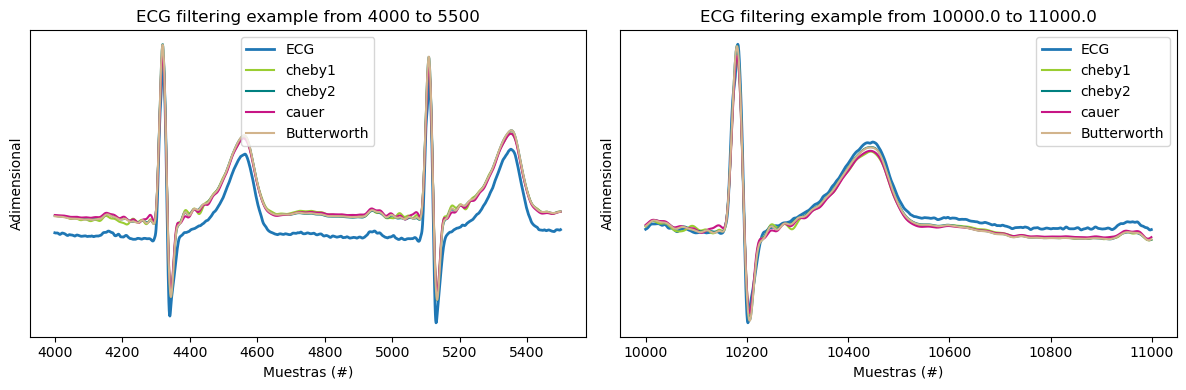

In [6]:
# Aplicamos el filtro 

ecg_but = sig.sosfiltfilt(sos_but, ecg_one_lead)
ecg_chb1 = sig.sosfiltfilt(sos_chb1, ecg_one_lead)
ecg_chb2 = sig.sosfiltfilt(sos_chb2, ecg_one_lead)
ecg_cau = sig.sosfiltfilt(sos_cau, ecg_one_lead)

# Regiones de interés sin ruido  
regs_interes = (
        [4000, 5500], # muestras
        [10e3, 11e3], # muestras
        )
 
fig, axes = plt.subplots(1, len(regs_interes), figsize=(6 * len(regs_interes), 4))

if len(regs_interes) == 1:
    axes = [axes]

for ax, ii in zip(axes, regs_interes):
   
    # intervalo limitado de 0 a cant_muestras
    zoom_region = np.arange(np.max([0, ii[0]]), np.min([N, ii[1]]), dtype='uint')
   
    ax.plot(zoom_region, ecg_one_lead[zoom_region], label='ECG', linewidth=2)
    ax.plot(zoom_region, ecg_chb1[zoom_region], label='cheby1', color='yellowgreen')
    ax.plot(zoom_region, ecg_chb2[zoom_region], label='cheby2', color='teal')
    ax.plot(zoom_region, ecg_cau[zoom_region], label='cauer', color='mediumvioletred')
    ax.plot(zoom_region, ecg_but[zoom_region], label='Butterworth', color='tan')

   
    ax.set_title('ECG filtering example from ' + str(ii[0]) + ' to ' + str(ii[1]))
    ax.set_ylabel('Adimensional')
    ax.set_xlabel('Muestras (#)')
    ax.legend()
    ax.set_yticks(())

plt.tight_layout()
plt.show()
 

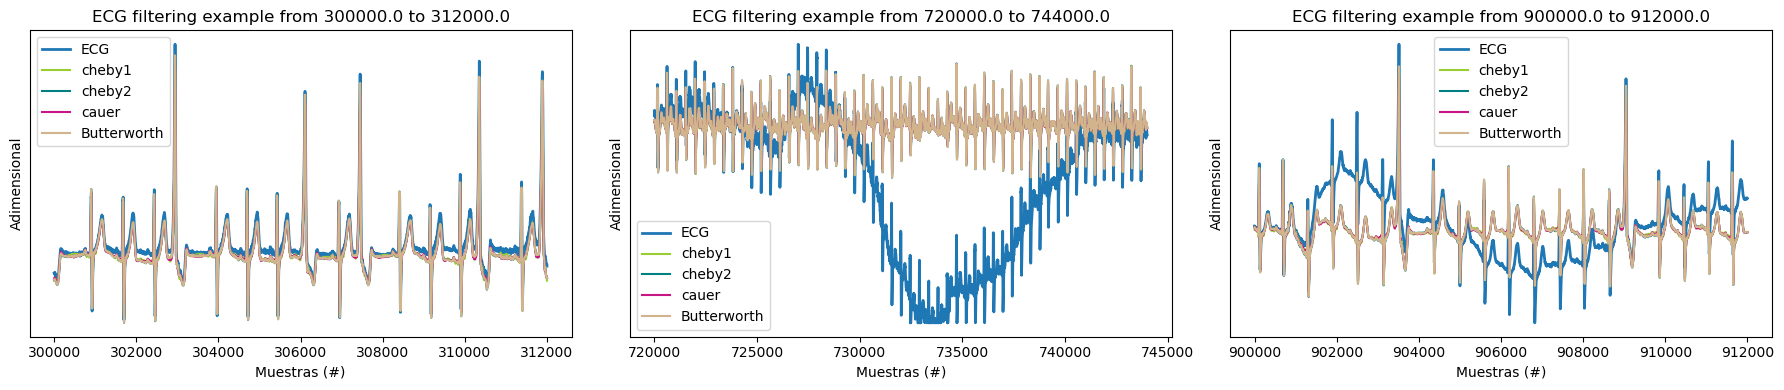

In [7]:
# Regiones de interés con ruido  
regs_interes = (
        np.array([5, 5.2]) *60*fs, # minutos a muestras
        np.array([12, 12.4]) *60*fs, # minutos a muestras
        np.array([15, 15.2]) *60*fs, # minutos a muestras
        )
 
fig, axes = plt.subplots(1, len(regs_interes), figsize=(6 * len(regs_interes), 4))

if len(regs_interes) == 1:
    axes = [axes]

for ax, ii in zip(axes, regs_interes):
   
    # intervalo limitado de 0 a cant_muestras
    zoom_region = np.arange(np.max([0, ii[0]]), np.min([N, ii[1]]), dtype='uint')
   
    ax.plot(zoom_region, ecg_one_lead[zoom_region], label='ECG', linewidth=2)
    ax.plot(zoom_region, ecg_chb1[zoom_region], label='cheby1', color='yellowgreen')
    ax.plot(zoom_region, ecg_chb2[zoom_region], label='cheby2', color='teal')
    ax.plot(zoom_region, ecg_cau[zoom_region], label='cauer', color='mediumvioletred')
    ax.plot(zoom_region, ecg_but[zoom_region], label='Butterworth', color='tan')
   
    ax.set_title('ECG filtering example from ' + str(ii[0]) + ' to ' + str(ii[1]))
    ax.set_ylabel('Adimensional')
    ax.set_xlabel('Muestras (#)')
    ax.legend()
    ax.set_yticks(())

plt.tight_layout()
plt.show()

**Regiones con ruido (alta frecuencia)**

En ambas ventanas temporales se observa que los cuatro filtros logran suprimir eficazmente el ruido de alta frecuencia presente en la señal original, produciendo trazos notablemente más suaves. Las señales filtradas se superponen casi por completo, lo que indica que las cuatro aproximaciones son equivalentes en términos de efectividad para esta región. Cabe destacar que la línea de base de la señal original presenta una deriva visible, que los filtros corrigen llevando el nivel isoeléctrico a cero.

**Regiones sin ruido (baja frecuencia)**
En las tres ventanas analizadas se aprecian comportamientos bien diferenciados según el nivel de perturbación presente:

- En la región de 300000 a 312000 muestras, la señal presenta un ruido de alta frecuencia moderado. Los filtros lo atenúan correctamente, preservando la morfología de los latidos.

- En la región de 720000 a 744000 muestras, se evidencia la interferencia más severa del registro. La señal original exhibe una oscilación de gran amplitud que enmascara completamente la señal cardíaca. Los filtros logran recuperar la forma general de la envolvente, aunque con mayor dificultad para reproducir los detalles finos de cada latido.

- En la región de 900000 a 912000 muestras, persiste un nivel de ruido elevado. Los filtros reducen la interferencia de forma satisfactoria, aunque se observan pequeñas discrepancias entre las distintas aproximaciones, siendo Butterworth y Chebyshev I los que producen trazos más suaves y regulares.

# Filtros FIR

## Método de ventanas

Para el diseño mediante el método de ventanas se utilizó la función firwin2 de scipy.signal, que permite especificar la respuesta en frecuencia deseada a partir de un conjunto de frecuencias y ganancias, y aproximarla mediante el enventanado de la respuesta al impulso ideal. Se evaluaron cuatro ventanas: Boxcar, Hamming, Hanning y Blackman, con un orden de filtro de $N=3001$ coeficientes.

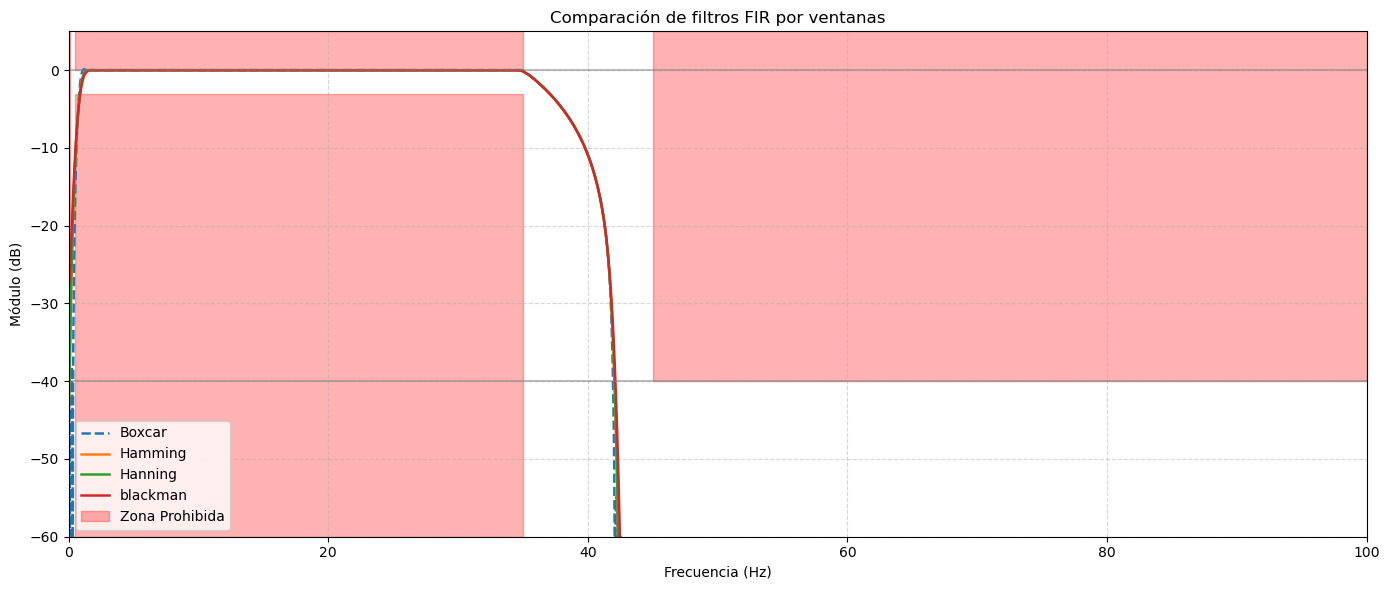

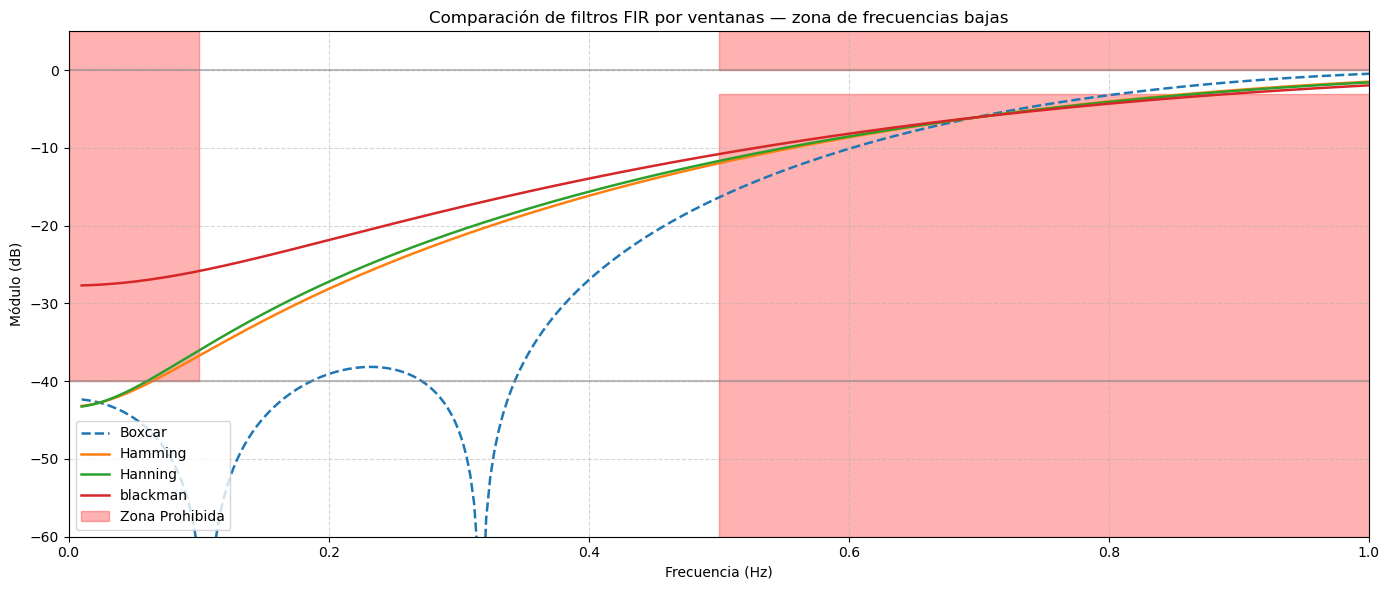

In [8]:
fs = 1000 # fs_ecg 
 
nyq_frec = fs/2
ripple = 1 # dB
atenuacion = 40 # dB
 
ws1 = 0.4
wp1 = 1
wp2 = 35
ws2 = 42

frecs = np.array([0.0,         ws1,         wp1,     wp2,     ws2,         nyq_frec   ])
gains_db = np.array([-atenuacion, -atenuacion, -ripple, -ripple, -atenuacion, -atenuacion])

wp = [wp1, wp2]
ws = [ws1, ws2]

numtaps = 3001
demora = (numtaps - 1)//2 

gain = np.array([0, 0, 1, 1, 0, 0])

b_win_box = sig.firwin2(numtaps, frecs, gain, nfreqs = 2**14, window='boxcar', fs=fs)
b_win_ham = sig.firwin2(numtaps, frecs, gain, nfreqs=2**14, window='hamming', fs=fs)
b_win_han = sig.firwin2(numtaps, frecs, gain, nfreqs=2**14, window='hann', fs=fs)
b_win_bla = sig.firwin2(numtaps, frecs, gain, nfreqs=2**14, window='blackman', fs=fs)

ww = np.concatenate([np.logspace(start=-2,stop = 0.1, num = 500),
                np.linspace(start = 1.26,stop = 35, num = 200),
                np.logspace(start=1.55,stop = 1.65, num = 300),
                np.linspace(start = 46,stop = fs//2, num = 50)])

filtros = [
    (b_win_box, 'Boxcar', 'C0', '--'),
    (b_win_ham,  'Hamming', 'C1', '-'),
    (b_win_han, 'Hanning', 'C2', '-'),
    (b_win_bla, 'blackman', 'C3', '-'),
]

eps = 1e-10 

plt.figure(figsize=(14, 6))

for b_win, label, color, ls in filtros:
    omega, H = sig.freqz(b_win, worN=ww, fs=fs)
    plt.plot(omega, 20 * np.log10(np.abs(H) + eps),
             label=label, color=color, linestyle=ls, linewidth=1.8)

limites_plantilla()

plt.title('Comparación de filtros FIR por ventanas')
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Módulo (dB)')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()

# Zoom para visualizar mejor las frecuencias bajas

plt.figure(figsize=(14, 6))

for b_win, label, color, ls in filtros:
    omega, H = sig.freqz(b_win, worN=ww, fs=fs)
    plt.plot(omega, 20 * np.log10(np.abs(H) + eps),
             label=label, color=color, linestyle=ls, linewidth=1.8)

limites_plantilla()
plt.xlim(0, 1)

plt.title('Comparación de filtros FIR por ventanas — zona de frecuencias bajas')
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Módulo (dB)')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()

Como se puede observar, los cuatro filtros cumplen con la plantilla en la vista general. Sin embargo, el zoom en la zona de frecuencias bajas revela diferencias importantes entre las ventanas utilizadas.

Boxcar presenta el comportamiento más irregular: su banda de rechazo inferior exhibe oscilaciones pronunciadas con nulos que llegan hasta $−60 dB$, pero con lóbulos secundarios que ascienden hasta cerca de $−40 dB$, rozando el límite de la zona prohibida. 

Hamming y Hanning muestran un comportamiento prácticamente idéntico entre sí, con una transición suave y monótonamente creciente desde la banda de rechazo hacia la banda de paso. Ambas permanecen bien por debajo de los $−40 dB$ requeridos en toda la zona de rechazo inferior.

Blackman, si bien cumple con la atenuación mínima, presenta la transición más lenta de todas. Su respuesta en frecuencias bajas se mantiene por encima de las otras ventanas enventanadas, lo que la convierte en la opción menos eficiente.

Cabe mencionar que, respecto a los parámetros de la plantilla original, se ajustaron los valores de $w_{s1}, w_{p1}$ y $w_{s2}$ con el fin de lograr una mejor adaptación sin necesitar en órdenes de filtro excesivamente elevados. El margen introducido en $w_{s2}$ busca evitar trabajar en condiciones límite de la especificación.

## Implementación de filtros FIR por método de ventanas

A continuación se aplican los filtros FIR diseñados por método de ventanas sobre la señal ecg_one_lead. A diferencia de los filtros IIR, aquí se utiliza lfilter en lugar de sosfiltfilt, por lo que el filtrado es causal e introduce una demora de $(N-1)/2$ muestras, que debe compensarse al momento de graficar.

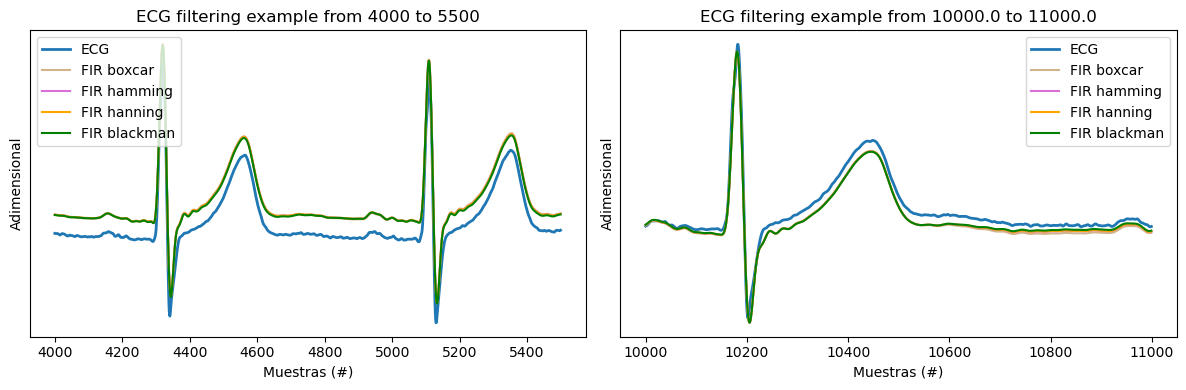

In [23]:
ecg_f_win_box = sig.lfilter(b_win_box, 1, ecg_one_lead)
ecg_f_win_ham = sig.lfilter(b_win_ham, 1, ecg_one_lead)
ecg_f_win_han = sig.lfilter(b_win_han, 1, ecg_one_lead)
ecg_f_win_bla = sig.lfilter(b_win_bla, 1, ecg_one_lead)

# Regiones de interés sin ruido  
regs_interes = (
        [4000, 5500], # muestras
        [10e3, 11e3], # muestras
        )
 
fig, axes = plt.subplots(1, len(regs_interes), figsize=(6 * len(regs_interes), 4))

if len(regs_interes) == 1:
    axes = [axes]

for ax, ii in zip(axes, regs_interes):
   
    # intervalo limitado de 0 a cant_muestras
    zoom_region = np.arange(np.max([0, ii[0]]), np.min([N, ii[1]]), dtype='uint')
   
    ax.plot(zoom_region, ecg_one_lead[zoom_region], label='ECG', linewidth=2)
    ax.plot(zoom_region, ecg_f_win_box[zoom_region + demora], label='FIR boxcar', color='tan')
    ax.plot(zoom_region, ecg_f_win_ham[zoom_region + demora], label='FIR hamming', color='orchid')
    ax.plot(zoom_region, ecg_f_win_han[zoom_region + demora], label='FIR hanning', color='orange')
    ax.plot(zoom_region, ecg_f_win_bla[zoom_region + demora], label='FIR blackman', color='green')
   
    ax.set_title('ECG filtering example from ' + str(ii[0]) + ' to ' + str(ii[1]))
    ax.set_ylabel('Adimensional')
    ax.set_xlabel('Muestras (#)')
    ax.legend()
    ax.set_yticks(())

plt.tight_layout()
plt.show()


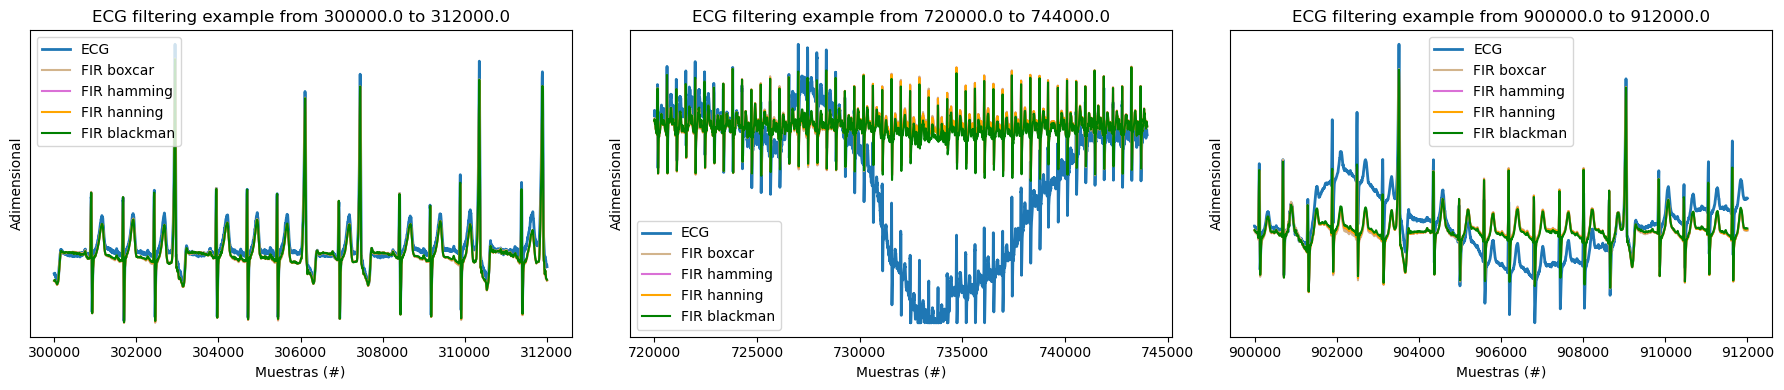

In [22]:
# Regiones de interés con ruido  
regs_interes = (
        np.array([5, 5.2]) *60*fs, # minutos a muestras
        np.array([12, 12.4]) *60*fs, # minutos a muestras
        np.array([15, 15.2]) *60*fs, # minutos a muestras
        )

fig, axes = plt.subplots(1, len(regs_interes), figsize=(6 * len(regs_interes), 4))

if len(regs_interes) == 1:
    axes = [axes]

for ax, ii in zip(axes, regs_interes):
   
    # intervalo limitado de 0 a cant_muestras
    zoom_region = np.arange(np.max([0, ii[0]]), np.min([N, ii[1]]), dtype='uint')
   
    ax.plot(zoom_region, ecg_one_lead[zoom_region], label='ECG', linewidth=2)
    ax.plot(zoom_region, ecg_f_win_box[zoom_region + demora], label='FIR boxcar', color='tan')
    ax.plot(zoom_region, ecg_f_win_ham[zoom_region + demora], label='FIR hamming', color='orchid')
    ax.plot(zoom_region, ecg_f_win_han[zoom_region + demora], label='FIR hanning', color='orange')
    ax.plot(zoom_region, ecg_f_win_bla[zoom_region + demora], label='FIR blackman', color='green')
   
    ax.set_title('ECG filtering example from ' + str(ii[0]) + ' to ' + str(ii[1]))
    ax.set_ylabel('Adimensional')
    ax.set_xlabel('Muestras (#)')
    ax.legend()
    ax.set_yticks(())

plt.tight_layout()
plt.show()

**Regiones con ruido (alta frecuencia)**

Los resultados son consistentes con los obtenidos mediante los filtros IIR: Boxcar, Hamming y Hanning logran suprimir eficazmente el ruido de alta frecuencia y corrigen la deriva de la línea de base, produciendo trazos prácticamente superpuestos. Blackman, en cambio, se separa visiblemente del resto, presentando una mayor distorsión en la morfología de los latidos, en particular en los picos de las ondas R. Esto es coherente con su transición más lenta observada en la respuesta en frecuencia.

**Regiones sin ruido (baja frecuencia)**

El comportamiento se replica en las tres ventanas temporales analizadas. Boxcar, Hamming y Hanning se superponen con gran precisión, mientras que Blackman se desvía de forma notable, especialmente en la región de 720000 a 744000 muestras donde la interferencia es más severa. 

En términos generales, el rendimiento de los filtros FIR por ventanas es comparable al de los filtros IIR, lo que sugiere que ambas familias son adecuadas para esta aplicación, siendo la elección entre ellas una cuestión de compromiso entre orden del filtro, fase lineal y complejidad computacional.

## Metodo de Cuadrados Mínimos y metodo de Parks-Mc Clellan-Remez.

Para el diseño mediante Cuadrados Mínimos se utilizó la función firls de scipy.signal, que minimiza el error cuadrático medio entre la respuesta en frecuencia obtenida y la deseada. Para el método de Parks-McClellan-Remez se empleó la función remez, que busca minimizar el error máximo (criterio minimax) en las bandas especificadas, garantizando una equirripple óptima. Ambos métodos requieren especificar explícitamente los vectores de frecuencias, ganancias deseadas y pesos por banda.


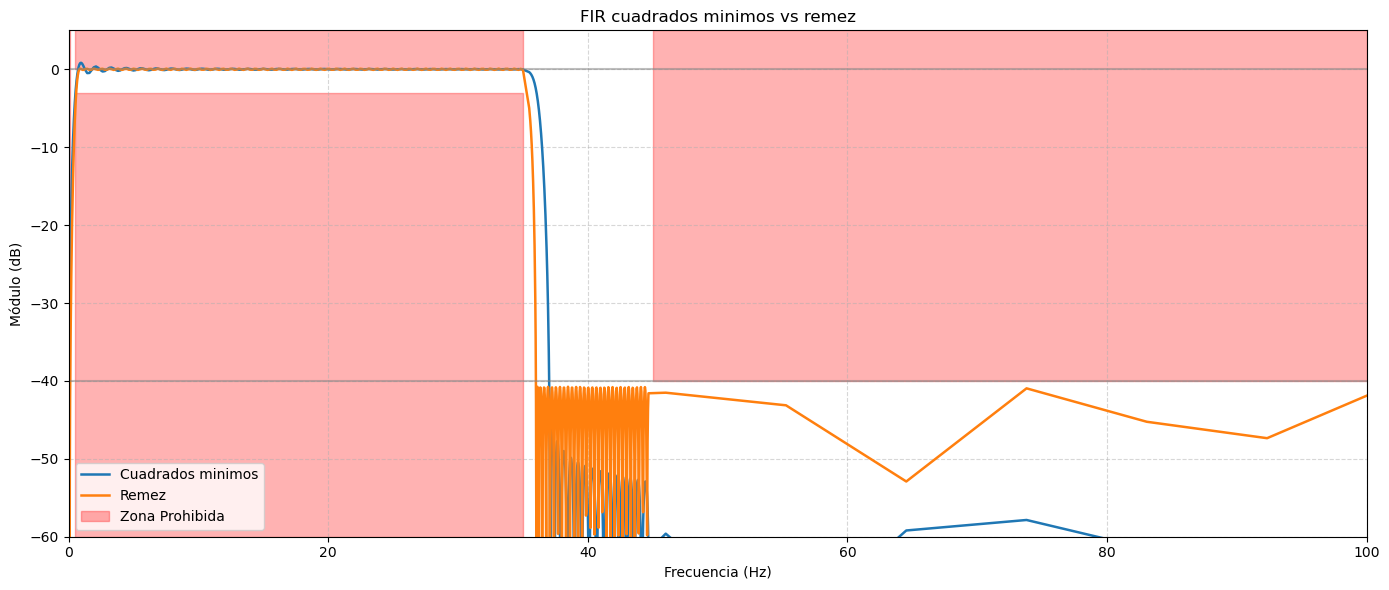

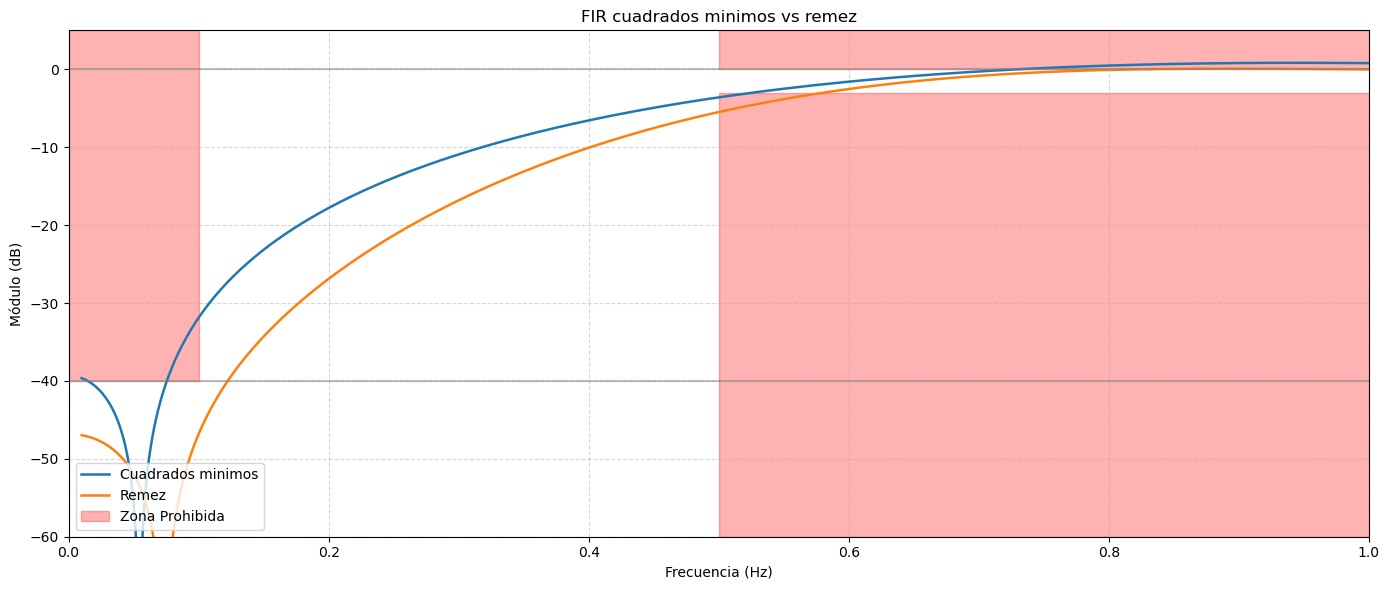

In [11]:

fs = 1000 # fs_ecg 
 
nyq_frec = fs/2
ripple = 1 # dB
atenuacion = 40 # dB

# Cuadrados Mínimos

ws1 = 0.2
wp1 = 0.5
wp2 = 35
ws2 = 37

frecs = np.array([0.0,         ws1,         wp1,     wp2,     ws2,         nyq_frec   ])
gains_db = np.array([-atenuacion, -atenuacion, -ripple, -ripple, -atenuacion, -atenuacion])

desired = np.array([0, 0, 1, 1, 0, 0])

wp = [wp1, wp2]
ws = [ws1, ws2]

numtaps = 1701
weight = np.array([2,1,1])

h_firls = sig.firls(numtaps=numtaps, bands=frecs, desired=desired, weight=weight, fs=fs)

ww = np.concat([np.logspace(start=-2,stop = 0.1, num = 500),
                np.linspace(start = 1.26,stop = 35, num = 200),
                np.logspace(start=1.55,stop = 1.65, num = 300),
                np.linspace(start = 46,stop = fs//2, num = 50)])

omega_firls, H_firls = sig.freqz(h_firls, worN=ww, fs=fs)

# Parks-Mc Clellan-Remez

ws1_rm = 0.1
wp1_rm  = 0.8
wp2_rm  = 35
ws2_rm  = 36

frecs_rm  = np.array([0.0,         ws1_rm ,         wp1_rm ,     wp2_rm ,     ws2_rm ,         nyq_frec   ])

numtaps_remez = 3200
desired_remez = np.array([0,1,0])
weight_remez = np.array([2,1,1])

h_remez = sig.remez(numtaps = numtaps_remez, bands = frecs_rm , desired = desired_remez, weight = weight_remez, fs = fs)  

omega_remez, H_remez = sig.freqz(h_remez, worN=ww, fs=fs)

eps = 1e-10

plt.figure(figsize=(14, 6))

plt.plot(omega_firls, 20 * np.log10(np.abs(H_firls) + eps), label='Cuadrados minimos', color='C0', linewidth=1.8)
plt.plot(omega_remez, 20 * np.log10(np.abs(H_remez) + eps), label='Remez', color='C1', linewidth=1.8)

limites_plantilla()
plt.title('FIR cuadrados minimos vs remez')
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Módulo (dB)')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()

# Zoom para visualizar mejor las frecuencias bajas

plt.figure(figsize=(14, 6))

plt.plot(omega_firls, 20 * np.log10(np.abs(H_firls) + eps), label='Cuadrados minimos', color='C0', linewidth=1.8)
plt.plot(omega_remez, 20 * np.log10(np.abs(H_remez) + eps), label='Remez', color='C1', linewidth=1.8)

limites_plantilla()
plt.xlim(0, 1)

plt.title('FIR cuadrados minimos vs remez')
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Módulo (dB)')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()


Ambos filtros cumplen con la plantilla en términos generales, aunque con diferencias notables en su comportamiento.

Cuadrados Mínimos presenta una transición muy abrupta hacia la banda de rechazo superior, con una atenuación que supera los $−60 dB$ en la zona de transición. En la banda de rechazo mantiene una respuesta uniforme y bien por debajo de los $−40 dB$ requeridos. Sin embargo, en la zona de frecuencias bajas su transición es más lenta que la de Remez, alcanzando los $−40 dB$ recién cerca de los $0.1 Hz$.

Remez, por su parte, exhibe el comportamiento equirripple característico del método. En la zona de transición superior se observan oscilaciones densas que rondan los $−40 dB$, manteniéndose siempre dentro de la zona permitida. En la banda de rechazo superior la atenuación no es tan uniforme como la de Cuadrados Mínimos, pero cumple con la especificación. En frecuencias bajas, Remez logra una caída más pronunciada que Cuadrados Mínimos, alcanzando los $−40 dB$ antes.

Al igual que en los casos anteriores, fue necesario ajustar los valores de $w_{s1}$, $w_{s2}$ y $w_{p2}$ respecto a la plantilla original para lograr una buena adaptación sin recurrir a órdenes de filtro excesivamente elevados.

## Implementación de filtros FIR por cuadrados mínimos y remez

A continuación se aplican ambos filtros sobre la señal ecg_one_lead utilizando lfilter. Dado que se trata de filtros FIR causales, se calcula la demora correspondiente a cada uno para compensar el desplazamiento temporal al momento de graficar.

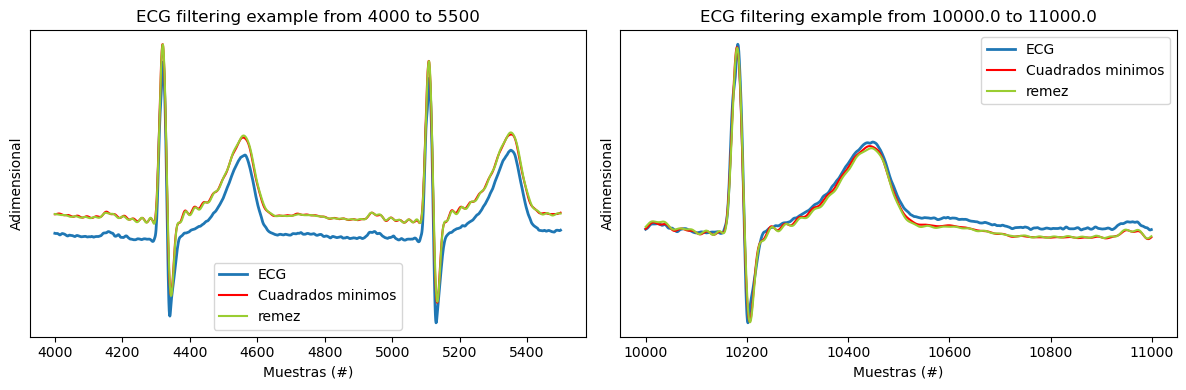

In [12]:
ecg_firls = sig.lfilter(h_firls, 1, ecg_one_lead)
ecg_remez = sig.lfilter(h_remez, 1, ecg_one_lead)

demora_firls = (numtaps - 1)//2 
demora_remez = (numtaps_remez - 1)//2 

# Regiones de interés sin ruido  
regs_interes = (
        [4000, 5500], # muestras
        [10e3, 11e3], # muestras
        )
 
fig, axes = plt.subplots(1, len(regs_interes), figsize=(6 * len(regs_interes), 4))

if len(regs_interes) == 1:
    axes = [axes]

for ax, ii in zip(axes, regs_interes):
   
    # intervalo limitado de 0 a cant_muestras
    zoom_region = np.arange(np.max([0, ii[0]]), np.min([N, ii[1]]), dtype='uint')
   
    ax.plot(zoom_region, ecg_one_lead[zoom_region], label='ECG', linewidth=2)
    ax.plot(zoom_region, ecg_firls[zoom_region + demora_firls], label='Cuadrados minimos', color='red')
    ax.plot(zoom_region, ecg_remez[zoom_region + demora_remez], label='remez', color='yellowgreen')
   
    ax.set_title('ECG filtering example from ' + str(ii[0]) + ' to ' + str(ii[1]))
    ax.set_ylabel('Adimensional')
    ax.set_xlabel('Muestras (#)')
    ax.legend()
    ax.set_yticks(())

plt.tight_layout()
plt.show()

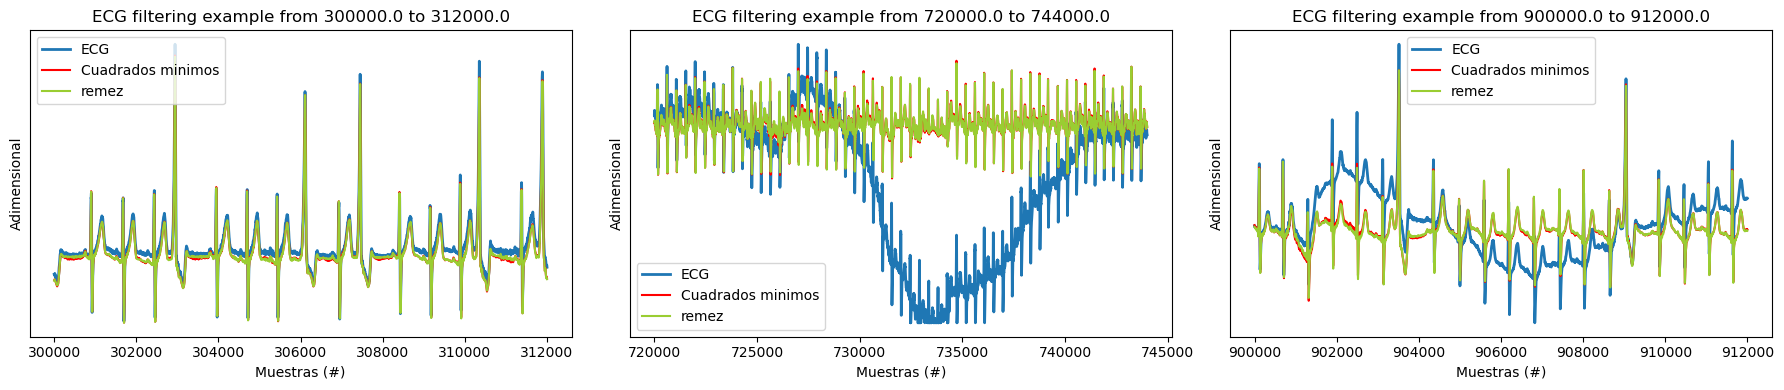

In [13]:
# Regiones de interés con ruido  
regs_interes = (
        np.array([5, 5.2]) *60*fs, # minutos a muestras
        np.array([12, 12.4]) *60*fs, # minutos a muestras
        np.array([15, 15.2]) *60*fs, # minutos a muestras
        )

fig, axes = plt.subplots(1, len(regs_interes), figsize=(6 * len(regs_interes), 4))

if len(regs_interes) == 1:
    axes = [axes]

for ax, ii in zip(axes, regs_interes):
   
    # intervalo limitado de 0 a cant_muestras
    zoom_region = np.arange(np.max([0, ii[0]]), np.min([N, ii[1]]), dtype='uint')
   
    ax.plot(zoom_region, ecg_one_lead[zoom_region], label='ECG', linewidth=2)
    ax.plot(zoom_region, ecg_firls[zoom_region + demora_firls], label='Cuadrados minimos', color='red')
    ax.plot(zoom_region, ecg_remez[zoom_region + demora_remez], label='remez', color='yellowgreen')
   
    ax.set_title('ECG filtering example from ' + str(ii[0]) + ' to ' + str(ii[1]))
    ax.set_ylabel('Adimensional')
    ax.set_xlabel('Muestras (#)')
    ax.legend()
    ax.set_yticks(())

plt.tight_layout()
plt.show()

**Regiones con ruido (alta frecuencia)**

Ambos filtros logran suprimir el ruido de alta frecuencia y corrigen la deriva de la línea de base de forma satisfactoria. No obstante, a diferencia de lo observado con los filtros IIR y FIR por ventanas, aquí se aprecia una separación visible entre Cuadrados Mínimos y Remez: mientras que Cuadrados Mínimos produce un trazo más suave y pegado a la morfología esperada, Remez presenta una leve diferencia en la línea de base, situándose ligeramente por encima.

**Regiones sin ruido (baja frecuencia)**

El comportamiento es consistente en las tres ventanas analizadas. En la región de 300000 a 312000 muestras ambos filtros se desempeñan de forma similar, atenuando correctamente el ruido y preservando la morfología de los latidos. En la región más perturbada (720000 a 744000 muestras), ambos logran recuperar la envolvente general de la señal, con resultados comparables a los obtenidos con los métodos anteriores. En la región de 900000 a 912000 muestras, Remez muestra oscilaciones algo más pronunciadas en la línea de base respecto a Cuadrados Mínimos, lo que es consistente con su comportamiento equirripple observado en la respuesta en frecuencia.

# Conclusiones

A lo largo de este trabajo se diseñaron e implementaron distintos filtros digitales para el procesamiento de una señal ECG registrada durante una prueba de esfuerzo. El objetivo fue mitigar las tres principales fuentes de contaminación presentes en el registro: el ruido de alta frecuencia por movimiento de electrodos y actividad muscular, y la deriva de baja frecuencia inducida por la respiración.

En cuanto a los filtros IIR, las cuatro aproximaciones evaluadas (Butterworth, Chebyshev I, Chebyshev II y Cauer) cumplieron con las especificaciones de la plantilla de diseño. Su principal ventaja radica en alcanzar los requerimientos de atenuación con órdenes de filtro significativamente menores que los FIR. Sin embargo, al utilizar *sosfiltfilt* para garantizar fase cero, el costo computacional se incrementa, reduciéndose en parte esta ventaja.

En cuanto a los filtros FIR, los métodos de ventanas, cuadrados mínimos y Remez produjeron resultados comparables entre sí y consistentes con los IIR. Dentro de esta familia, el método de Cuadrados Mínimos se destacó como la opción más equilibrada: logró una transición abrupta hacia la banda de rechazo superior, una atenuación uniforme y bien por debajo de los $−40 dB$ requeridos, y un comportamiento más regular en la línea de base respecto a Remez. A diferencia de este último, no presenta el rizado equirripple en la zona de transición, lo que se traduce en una respuesta más predecible y suave sobre la señal filtrada.

En términos generales, ambas familias de filtros demostraron ser adecuadas para la aplicación. La elección entre IIR y FIR depende del contexto: los IIR son preferibles cuando el orden del filtro es una restricción crítica, mientras que los FIR garantizan fase lineal exacta, lo que resulta especialmente relevante en señales biomédicas donde la preservación de la morfología de los latidos es prioritaria.